# Кластеризация данных сотрудников

Это набор данных предоставляет 10000 записей о сотрудниках.Данный набор предназначен для анализа кадровых тенденций, эффективности сотрудников, производительности и внутренних взаимодействиях в компании.


# Описание набора данных

База данных сотрудников содержит персональную информацию, контактные данные и сведения о должностях 10 000 работников.
Расшифровка каждого атрибута:
- Index - персональный индекс сотрудника
- First name - Имя сотрудника
- Last name - Фамилия сотрудника
- Sex - Пол сотрудника
- Email - Почта сотрудника
- Phone - Телефон сотрудника
- Date of birth - День рождения сотрудника
- Job Title - Должность

# Загрузка данных

## Подключение необходимых библиотек и функций

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install openpyxl
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Обзор датасета

In [56]:
df = pd.read_csv("Employee 1000x.csv")

In [57]:
df

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor
...,...,...,...,...,...,...,...,...
9995,9996,Tina,Sherman,Male,bartlettcolleen@example.org,(455)476-4044x5755,28-07-74,"Scientist, physiological"
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,20-08-32,Warehouse manager
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,06-06-66,Lawyer
9998,9999,Emma,Clark,Male,pstrickland@example.com,849-868-8653,09-05-07,Accounting technician


# Разведочный анализ

## Общая информация

In [58]:
df.shape

(10000, 8)

Датасет хранит в себе 10000 записей и 8 столбцов.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          10000 non-null  int64 
 1   First Name     10000 non-null  object
 2   Last Name      10000 non-null  object
 3   Sex            10000 non-null  object
 4   Email          10000 non-null  object
 5   Phone          10000 non-null  object
 6   Date of birth  10000 non-null  object
 7   Job Title      10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


Датасет полностью заполнен, содержит 8 колонок и 10 тысяч записей. Типы данных: одна колонка числовая, а остальные — текстовые.

In [60]:
df.describe(include = "O")

,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
count,10000,10000,10000,10000,10000,10000,10000
unique,690,1000,2,9936,9992,8646,639
top,Martin,Velazquez,Female,bnorton@example.net,-10092,19-01-11,Film/video editor
freq,28,22,5074,3,2,4,30


Этот набор не содержит пропуски. Однако в номерах телефона присутствуют аномалии.

In [61]:
print(df.duplicated().sum())

0


Дубликаты не найдены.

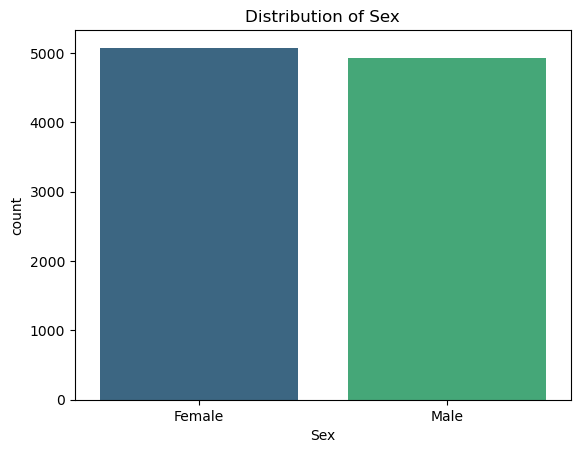

In [62]:
sns.countplot(data=df, x='Sex', palette='viridis')
plt.title('Distribution of Sex')
plt.show()

In [86]:
df['Sex'] = df['Sex'].replace({'Female': 1, 'Male': 0})


В компании женщин немного больше,чем мужчин

In [63]:
df["Job Title"].value_counts()

Job Title
Film/video editor           30
Wellsite geologist          28
Medical secretary           28
Exhibition designer         27
Probation officer           27
                            ..
Waste management officer     7
Press sub                    7
Chief Financial Officer      5
Holiday representative       5
Theatre director             5
Name: count, Length: 639, dtype: int64

более популярная должность это видеоредактор. Но нельзя сказать,что она распространена в компании т.к. записей всего 10000.

In [64]:
df["Date of birth"] = pd.to_datetime(df["Date of birth"],format = "%d-%m-%y",errors = "coerce")

In [65]:
df["Year"] = df["Date of birth"].dt.year
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",2021
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,1969
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,2015
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,1978
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,1989


Исправили формат дня рождения и вывели год в отдельный столбец

In [66]:
df["Age"] = 2026 - df["Year"]

In [67]:
df["Age"]

0        5
1       57
2       11
3       48
4       37
        ..
9995    52
9996    -6
9997   -40
9998    19
9999    -9
Name: Age, Length: 10000, dtype: int32

Мы четко увидели аномалии в возрасте.Попытаемся исправить их

In [68]:
from pandas.tseries.offsets import DateOffset

In [69]:
df["Original date"] = df["Date of birth"]
df.loc[df["Age"] < 0, "Date of birth"] -= DateOffset(years = 100)
df["Update Age"] = 2025 - df["Date of birth"].dt.year

In [70]:
df.loc[df["Age"]< 0]

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year,Age,Original date,Update Age
14,15,Clayton,Erickson,Male,nterry@example.net,990-374-0521x33156,1959-02-07,Paediatric nurse,2059,-33,2059-02-07,66
19,20,Jon,Wagner,Female,meagan99@example.org,001-940-671-0693x345,1934-01-06,"Engineer, aeronautical",2034,-8,2034-01-06,91
20,21,Glen,Calderon,Male,randystephenson@example.net,4890361487,1944-09-16,"Research officer, government",2044,-18,2044-09-16,81
21,22,Marco,Sharp,Male,cmcclure@example.net,074-415-1149,1944-04-09,Retail buyer,2044,-18,2044-04-09,81
24,25,Meghan,Blanchard,Male,smejia@example.org,+1-188-201-3028x13440,1927-08-24,Occupational therapist,2027,-1,2027-08-24,98
...,...,...,...,...,...,...,...,...,...,...,...,...
9992,9993,Marvin,Davenport,Female,jade07@example.net,400-198-5125,1929-10-18,Restaurant manager,2029,-3,2029-10-18,96
9993,9994,Eddie,Clements,Female,chelsey82@example.net,855.007.8490x535,1938-06-15,Control and instrumentation engineer,2038,-12,2038-06-15,87
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,1932-08-20,Warehouse manager,2032,-6,2032-08-20,93
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,1966-06-06,Lawyer,2066,-40,2066-06-06,59


In [71]:
df = df.drop(columns = ["Year", "Age", "Original date"])
df.rename(columns = {"Update Age" : "Age"}, inplace=True)

In [72]:
bins = [17,25,35,45,55,100]
labels = ["A", "B", "C", "D", "E"]
df["Age Group"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [73]:
import pandas as pd
import numpy as np

df["Job Category"] = df["Job Title"]

# Существующие категории
education = df["Job Category"].str.contains(r'\b(professor|teacher|lecturer|tutor|instructor)\b', 
                                           regex=True, case=False, na=False)

administration = df["Job Category"].str.contains(r'\b(officer|secretary|administrator|clerk|assistant)\b', 
                                                regex=True, case=False, na=False)

healthcare = df["Job Category"].str.contains(
    r'\b(nurse|health|doctor|dentist|clinical|medical|therapist|psychologist|embryologist|radiographer|podiatrist|haematologist|psychotherapist|pathologist|pharmacist|veterinarian|physiotherapist|neurosurgeon|surgeon|optometrist|orthoptist|radiation|practitioner)\b',
    regex=True, case=False, na=False
)

manager = df["Job Category"].str.contains(r'\b(manager|director|supervisor|head|chief)\b', 
                                         regex=True, case=False, na=False)

tech = df["Job Category"].str.contains(r'\b(analyst|programmer|scientist|developer|specialist|technician|IT)\b', 
                                      regex=True, case=False, na=False)

engineer = df["Job Category"].str.contains(r'\b(engineer|engineering|geologist|surveyor)\b', 
                                          regex=True, case=False, na=False)

design = df["Job Category"].str.contains(r'\b(designer|editor|artist|creative|video|film|broadcast|journalist|camera|writer|copywriter|illustrator|animator|producer|lexicographer)\b', 
                                        regex=True, case=False, na=False)

consultant_sales = df["Job Category"].str.contains(r'\b(consultant|agent|representative|sales|buyer|pensions|retail|marketing|executive|account executive)\b', 
                                                  regex=True, case=False, na=False)

planning = df["Job Category"].str.contains(r'\b(planner|town planner|urban|regional|development|surveyor|event organiser|architect|landscape)\b', 
                                          regex=True, case=False, na=False)

social = df["Job Category"].str.contains(r'\b(counsellor|psychotherapist|social worker|probation|youth|community|family|careers adviser|guidance)\b', 
                                        regex=True, case=False, na=False)

# НОВЫЕ КАТЕГОРИИ
science_research = df["Job Category"].str.contains(
    r'\b(scientist|researcher|analytical chemist|chemist|biologist|physicist|geoscientist|seismologist|herpetologist|ergonomist|hygienist|technologist|field|laboratory|lab)\b',
    regex=True, case=False, na=False
)

library_heritage = df["Job Category"].str.contains(
    r'\b(librarian|public librarian|archivist|curator|conservator|restorer|museum|gallery|heritage)\b',
    regex=True, case=False, na=False
)

finance_legal = df["Job Category"].str.contains(
    r'\b(tax|accountant|auditor|loss adjuster|chartered|investment|banker|corporate|legal|executive|solicitor|paralegal)\b',
    regex=True, case=False, na=False
)

agriculture_environment = df["Job Category"].str.contains(
    r'\b(horticulturist|amenity|agriculture|farmer|gardener|environmental|ecologist|conservation|forestry)\b',
    regex=True, case=False, na=False
)

emergency_security = df["Job Category"].str.contains(
    r'\b(firefighter|police|paramedic|emergency|rescue|security|safety|protection)\b',
    regex=True, case=False, na=False
)

# Дополнительная категория для текстильных технологов и т.д.
textile_garment = df["Job Category"].str.contains(
    r'\b(garment|textile|technologist|fashion|clothing|apparel)\b',
    regex=True, case=False, na=False
)

# Дополнительная категория для авиации
aviation = df["Job Category"].str.contains(
    r'\b(air cabin crew|pilot|flight|aviation|airline|aircraft)\b',
    regex=True, case=False, na=False
)

# ВАЖНО: other создается ПОСЛЕ ВСЕХ категорий
other = ~(education | administration | healthcare | manager | tech | engineer | 
          design | consultant_sales | planning | social | science_research |
          library_heritage | finance_legal | agriculture_environment | 
          emergency_security | textile_garment | aviation)

# Все условия в правильном порядке
conditions = [
    education, administration, healthcare, manager, tech, engineer, 
    design, consultant_sales, planning, social, science_research,
    library_heritage, finance_legal, agriculture_environment, 
    emergency_security, textile_garment, aviation, other
]

choices = [
    "education", "administration", "healthcare", "manager", "tech", "engineer",
    "design", "consultant_sales", "planning", "social", "science_research",
    "library_heritage", "finance_legal", "agriculture_environment",
    "emergency_security", "textile_garment", "aviation", "other"
]

df["Job Category"] = np.select(conditions, choices, default="other")

# Проверяем результат
print(df["Job Category"].value_counts())

# Проверка конкретных профессий
print("\nПроверка классификации:")
for prof in ["Writer", "Librarian, public", "Tax inspector", "Neurosurgeon", 
             "Firefighter", "Air cabin crew", "Herpetologist"]:
    mask = df["Job Title"] == prof
    if mask.any():
        cat = df.loc[mask, "Job Category"].iloc[0]
        print(f"{prof}: {cat}")

Job Category
healthcare                 1406
administration             1383
engineer                   1353
other                      1324
design                      958
manager                     799
tech                        714
consultant_sales            377
finance_legal               347
education                   329
science_research            306
planning                    237
library_heritage            184
social                      125
agriculture_environment      80
aviation                     46
emergency_security           32
Name: count, dtype: int64

Проверка классификации:
Writer: design
Librarian, public: library_heritage
Tax inspector: finance_legal
Neurosurgeon: healthcare
Firefighter: emergency_security
Air cabin crew: aviation
Herpetologist: science_research


Вместо конкретных должностей поменяла на обобщенные категории

In [74]:
adult = df[df["Age"] >= 18]
mean_age_category = adult.groupby("Job Category")["Age"].mean()
def solve_age (row):
    if row["Age"] <= 18:
        return mean_age_category.get(row["Job Category"], np.nan)
    return row["Age"]

df["Right Age"] = df.apply(solve_age, axis = 1)

In [75]:
df["Age Group"] = pd.cut(df["Right Age"], bins = bins, labels = labels)
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57.643875
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57.091603
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47.000000
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36.000000


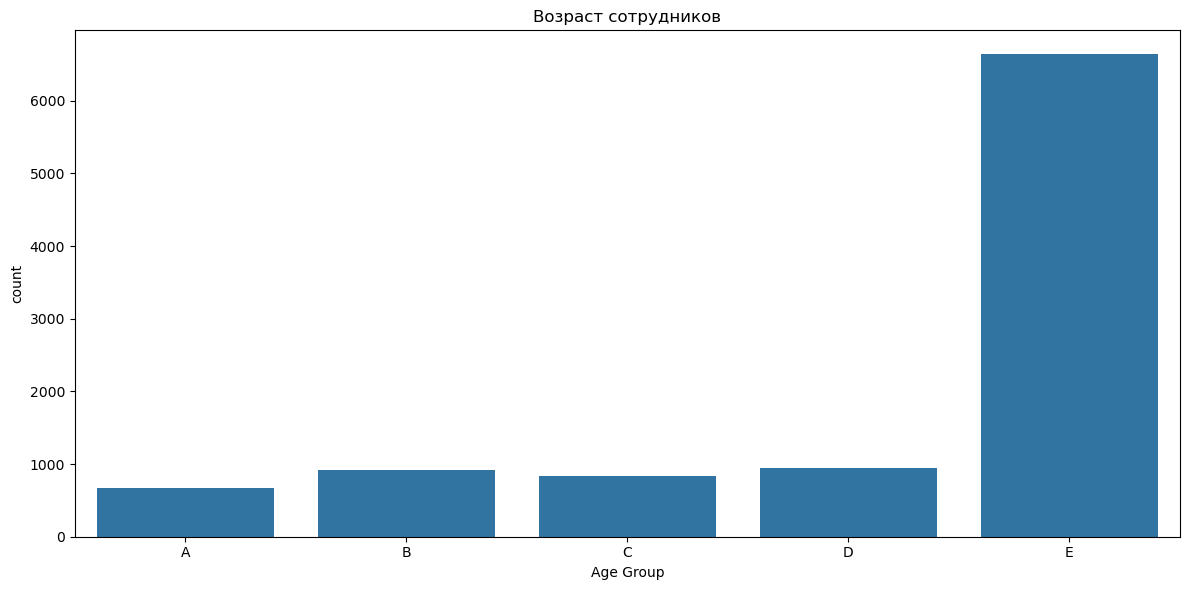

In [76]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age Group')
plt.title('Возраст сотрудников')
plt.tight_layout()
plt.show()

- Группа А(от 18 до 25 лет)
- Группа B(от 26 до 35 лет)
- Группа C(от 36 до 45 лет)
- Группа D(от 46 до 55 лет)
- Группа E(от 56 до 100 лет)
  Как мы видим группа E превосходит численностью.

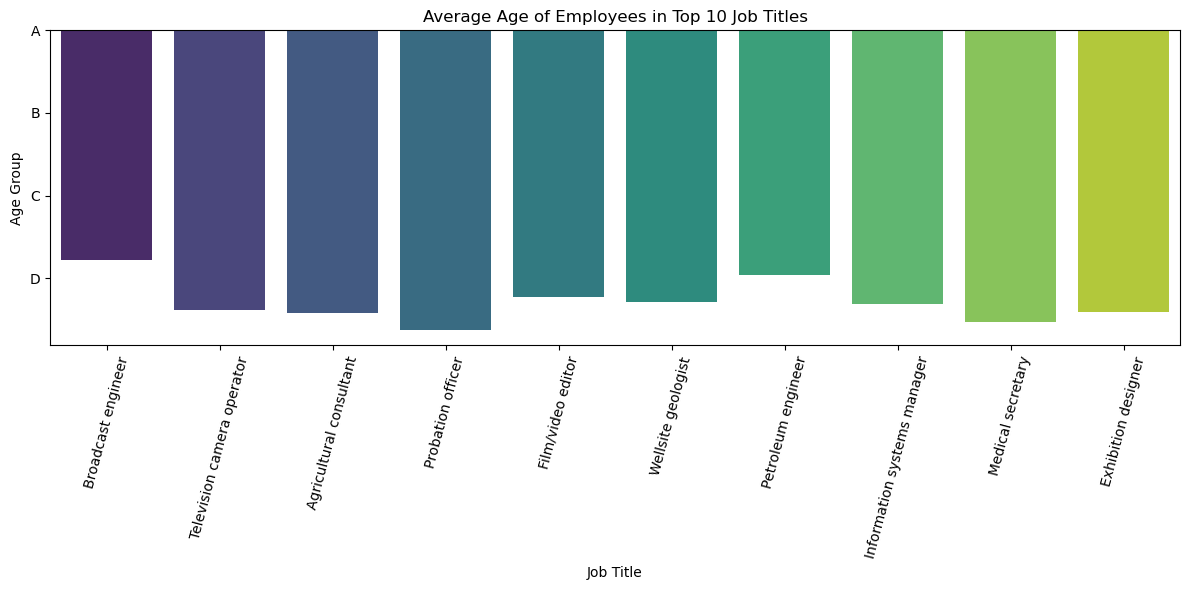

In [77]:
top_10_jobs = df["Job Title"].value_counts().head(10).index
top_10_job_data = df[df["Job Title"].isin(top_10_jobs)]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
plt.title("Average Age of Employees in Top 10 Job Titles")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [78]:
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57.643875
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57.091603
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47.000000
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36.000000


In [79]:
df['Right Age'] = df['Right Age'].astype(int)


In [87]:
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,1,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57
1,2,Alisha,Hebert,0,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56
2,3,Gwendolyn,Sheppard,0,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57
3,4,Kristine,Mccann,1,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47
4,5,Bobby,Pittman,1,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36


In [93]:
df["Job Category"].value_counts().head(35)

Job Category
healthcare                 1406
administration             1383
engineer                   1353
other                      1324
design                      958
manager                     799
tech                        714
consultant_sales            377
finance_legal               347
education                   329
science_research            306
planning                    237
library_heritage            184
social                      125
agriculture_environment      80
aviation                     46
emergency_security           32
Name: count, dtype: int64

In [82]:
df["Job Title"].value_counts().head(50)

Job Title
Film/video editor                              30
Wellsite geologist                             28
Medical secretary                              28
Exhibition designer                            27
Probation officer                              27
Broadcast engineer                             27
Information systems manager                    26
Agricultural consultant                        26
Petroleum engineer                             26
Television camera operator                     26
Advertising account planner                    26
Counsellor                                     26
Therapeutic radiographer                       25
Financial manager                              25
Pensions consultant                            25
Retail buyer                                   25
Writer                                         25
Radiographer, diagnostic                       24
Video editor                                   24
Regulatory affairs officer              

In [83]:
# Посмотрим топ-20 профессий в other
other_professions = df[df["Job Category"] == "other"]["Job Title"].value_counts().head(40)
print("Топ-20 неклассифицированных профессий:")
print(other_professions)

# Посмотрим уникальные профессии в other
unique_other = df[df["Job Category"] == "other"]["Job Title"].nunique()
print(f"\nУникальных профессий в other: {unique_other}")

Топ-20 неклассифицированных профессий:
Job Title
Visual merchandiser            21
Copy                           20
Barista                        18
Bonds trader                   18
Economist                      18
Ranger/warden                  18
Printmaker                     18
Patent attorney                17
Charity fundraiser             17
Midwife                        17
Bookseller                     17
Trade mark attorney            17
Financial adviser              17
Dancer                         17
Geochemist                     17
Osteopath                      16
Chiropractor                   16
Freight forwarder              16
Sub                            16
Hydrogeologist                 16
Actuary                        16
Civil Service fast streamer    16
Insurance underwriter          16
Air broker                     16
Financial controller           15
Dramatherapist                 15
Plant breeder/geneticist       15
Lobbyist                       15

In [84]:
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36


In [88]:
X = df[["Job Category","Sex"]]
X.head()

,Job Category,Sex
0,design,1
1,engineer,0
2,consultant_sales,0
3,tech,1
4,engineer,1


КЛАСТЕРИЗАЦИЯ ДАННЫХ

📊 МЕТРИКИ КЛАСТЕРИЗАЦИИ:
               Silhouette  Calinski-Harabasz  Davies-Bouldin
K-Means            0.3933          5116.4972          1.0211
Agglomerative      0.3237          4005.8567          1.2845
DBSCAN             0.3518          3846.5838          1.2979

✅ Лучший метод по силуэту: K-Means

📈 Объясненная дисперсия PCA: 66.97%


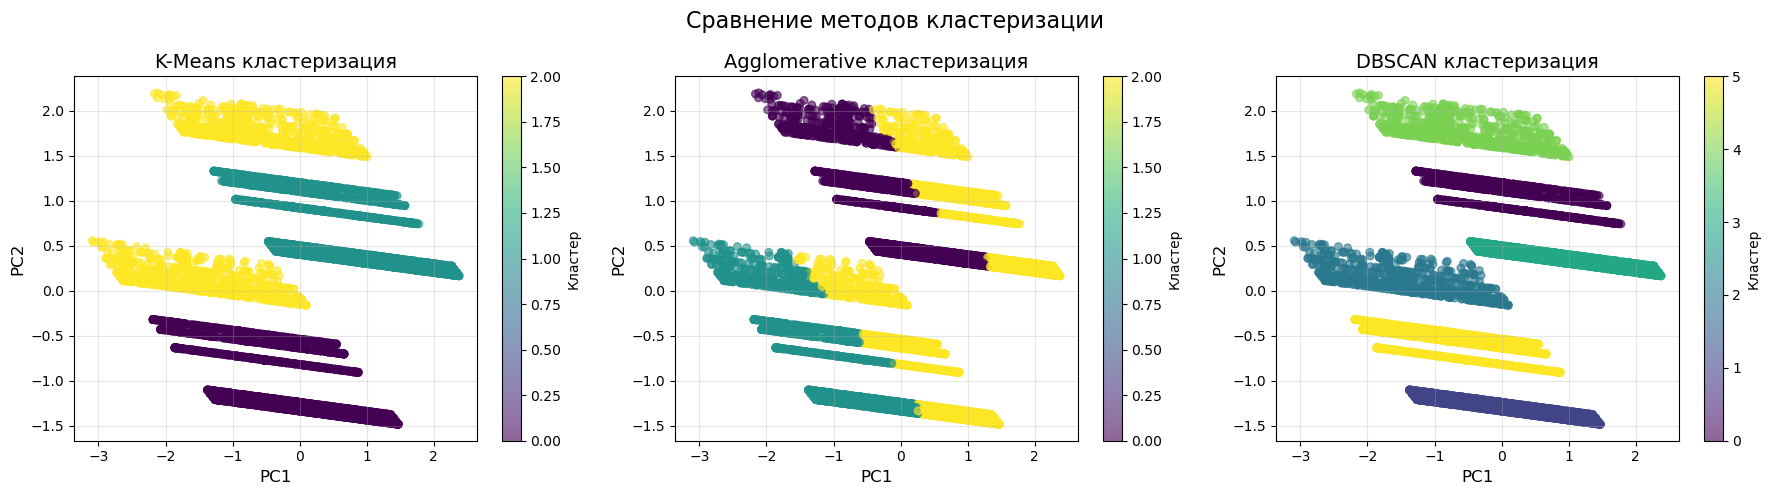


📊 ПРОФИЛЬ КЛАСТЕРОВ (K-MEANS)
         Ср.возраст  Стд.возраст  Мин.возраст  Макс.возраст  Кол-во  \
Cluster                                                               
0             57.47        19.73           19            98    3897   
1             57.58        19.48           19            98    4040   
2             57.00        19.29           19            98    2063   

         Доля женщин     Топ-профессия  
Cluster                                 
0                0.0        healthcare  
1                1.0        healthcare  
2                0.5  consultant_sales  

🏢 ДЕТАЛЬНЫЙ СОСТАВ ПРОФЕССИЙ ПО КЛАСТЕРАМ

🔹 КЛАСТЕР 0 (n=3897 человек, 39.0% выборки)
   Возраст: от 19 до 98 (ср.57.5)
   Пол: 0.0% женщин
   ТОП-5 ПРОФЕССИЙ:
     • healthcare: 697 чел. (17.9%)
     • administration: 691 чел. (17.7%)
     • engineer: 679 чел. (17.4%)
     • other: 628 чел. (16.1%)
     • design: 458 чел. (11.8%)

🔹 КЛАСТЕР 1 (n=4040 человек, 40.4% выборки)
   Возраст: от 19 до 98 (ср.

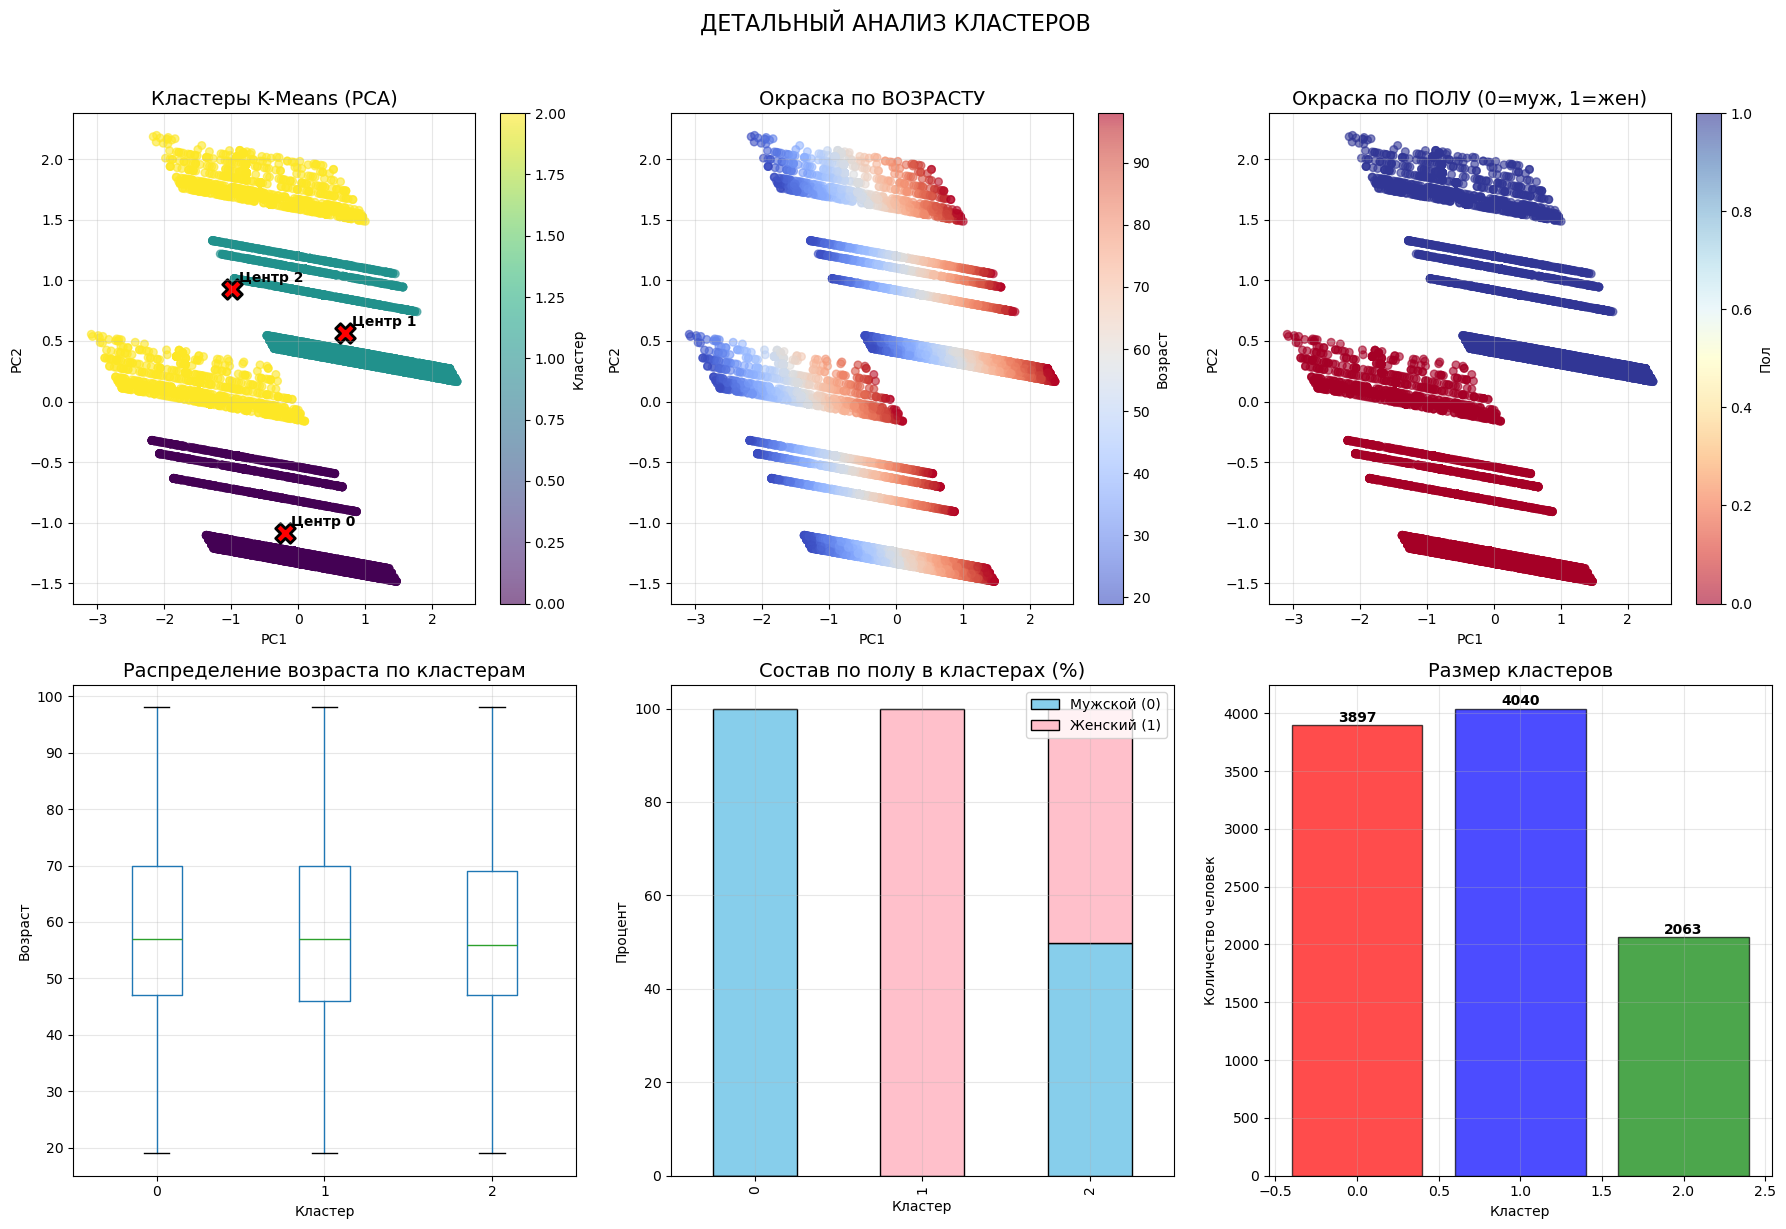


📝 ОПИСАНИЕ КЛАСТЕРОВ ДЛЯ ОТЧЕТА

🔹 КЛАСТЕР 0: 👴 Опытные специалисты
   • Размер: 3897 человек (39.0% от выборки)
   • Возраст: от 19 до 98 лет (средний 57.5)
   • Пол: преимущественно мужской (0.0% женщин)
   • Основная профессия: healthcare (17.9%)
   • Вторая профессия: administration (17.7%)

🔹 КЛАСТЕР 1: 👴 Опытные специалисты
   • Размер: 4040 человек (40.4% от выборки)
   • Возраст: от 19 до 98 лет (средний 57.6)
   • Пол: преимущественно женский (100.0% женщин)
   • Основная профессия: healthcare (17.5%)
   • Вторая профессия: other (17.2%)

🔹 КЛАСТЕР 2: 👴 Опытные специалисты
   • Размер: 2063 человек (20.6% от выборки)
   • Возраст: от 19 до 98 лет (средний 57.0)
   • Пол: смешанный (50.1% женщин)
   • Основная профессия: consultant_sales (18.3%)
   • Вторая профессия: finance_legal (16.8%)

🎯 ВЫВОДЫ ПО КЛАСТЕРИЗАЦИИ

1. ЛУЧШИЙ МЕТОД: K-Means (показал наивысший силуэт и лучшие метрики)
   
2. КОЛИЧЕСТВО КЛАСТЕРОВ: 3 (оптимально для данных)

3. ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:
   • Кла

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

 
freq_map = df['Job Category'].value_counts().to_dict()
df['Job_freq'] = df['Job Category'].map(freq_map)

 features = df[['Right Age', 'Sex', 'Job_freq']].copy()

 scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

 
print("="*70)
print("КЛАСТЕРИЗАЦИЯ ДАННЫХ")
print("="*70)

clustering_results = {}
metrics = {}


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_results['K-Means'] = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
clustering_results['Agglomerative'] = agglo.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
clustering_results['DBSCAN'] = dbscan.fit_predict(X_scaled)

 
for name, labels in clustering_results.items():
    if len(set(labels)) > 1:   
        metrics[name] = {
            'Silhouette': silhouette_score(X_scaled, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
            'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)
        }

metrics_df = pd.DataFrame(metrics).T
print("\nМЕТРИКИ КЛАСТЕРИЗАЦИИ:")
print(metrics_df.round(4))

 
best_method = metrics_df['Silhouette'].idxmax()
print(f"\n Лучший метод по силуэту: {best_method}")

 
 

 pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\n Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, labels) in zip(axes, clustering_results.items()):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title(f'{name} кластеризация', fontsize=14)
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    plt.colorbar(scatter, ax=ax, label='Кластер')
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение методов кластеризации', fontsize=16)
plt.tight_layout()
plt.show()

 
df['Cluster'] = clustering_results['K-Means']

print("\n" + "="*70)
print(" ПРОФИЛЬ КЛАСТЕРОВ (K-MEANS)")
print("="*70)

cluster_stats = df.groupby('Cluster').agg({
    'Right Age': ['mean', 'std', 'min', 'max', 'count'],
    'Sex': 'mean',
    'Job Category': lambda x: x.value_counts().index[0],   
}).round(2)

cluster_stats.columns = ['Ср.возраст', 'Стд.возраст', 'Мин.возраст', 
                         'Макс.возраст', 'Кол-во', 'Доля женщин', 'Топ-профессия']
print(cluster_stats)

print("\n" + "="*70)
print(" ДЕТАЛЬНЫЙ СОСТАВ ПРОФЕССИЙ ПО КЛАСТЕРАМ")
print("="*70)

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\n🔹 КЛАСТЕР {cluster} (n={len(cluster_data)} человек, {len(cluster_data)/len(df)*100:.1f}% выборки)")
    print(f"   Возраст: от {cluster_data['Right Age'].min():.0f} до {cluster_data['Right Age'].max():.0f} (ср.{cluster_data['Right Age'].mean():.1f})")
    print(f"   Пол: {cluster_data['Sex'].mean()*100:.1f}% женщин")
    print("   ТОП-5 ПРОФЕССИЙ:")
    
    top5 = cluster_data['Job Category'].value_counts().head(5)
    for job, count in top5.items():
        pct = count/len(cluster_data)*100
        print(f"     • {job}: {count} чел. ({pct:.1f}%)")

 

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

scatter1 = axes[0,0].scatter(X_pca[:, 0], X_pca[:, 1], 
                            c=df['Cluster'], cmap='viridis', alpha=0.6, s=30)
axes[0,0].set_title('Кластеры K-Means (PCA)', fontsize=14)
axes[0,0].set_xlabel('PC1')
axes[0,0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0,0], label='Кластер')
axes[0,0].grid(True, alpha=0.3)

for cluster in sorted(df['Cluster'].unique()):
    center = X_pca[df['Cluster'] == cluster].mean(axis=0)
    axes[0,0].scatter(center[0], center[1], 
                     c='red', marker='X', s=200, edgecolors='black', linewidth=2)
    axes[0,0].annotate(f'Центр {cluster}', center, 
                      fontsize=10, weight='bold',
                      xytext=(5, 5), textcoords='offset points')

scatter2 = axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], 
                            c=df['Right Age'], cmap='coolwarm', alpha=0.6, s=30)
axes[0,1].set_title('Окраска по ВОЗРАСТУ', fontsize=14)
axes[0,1].set_xlabel('PC1')
axes[0,1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[0,1], label='Возраст')
axes[0,1].grid(True, alpha=0.3)

 scatter3 = axes[0,2].scatter(X_pca[:, 0], X_pca[:, 1], 
                            c=df['Sex'], cmap='RdYlBu', alpha=0.6, s=30)
axes[0,2].set_title('Окраска по ПОЛУ (0=муж, 1=жен)', fontsize=14)
axes[0,2].set_xlabel('PC1')
axes[0,2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[0,2], label='Пол')
axes[0,2].grid(True, alpha=0.3)

# 4. Распределение возраста по кластерам
df.boxplot(column='Right Age', by='Cluster', ax=axes[1,0])
axes[1,0].set_title('Распределение возраста по кластерам', fontsize=14)
axes[1,0].set_xlabel('Кластер')
axes[1,0].set_ylabel('Возраст')
axes[1,0].grid(True, alpha=0.3)

sex_by_cluster = pd.crosstab(df['Cluster'], df['Sex'], normalize='index') * 100
sex_by_cluster.columns = ['Мужской (0)', 'Женский (1)']
sex_by_cluster.plot(kind='bar', stacked=True, ax=axes[1,1], 
                   color=['skyblue', 'pink'], edgecolor='black')
axes[1,1].set_title('Состав по полу в кластерах (%)', fontsize=14)
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Процент')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

 cluster_sizes = df['Cluster'].value_counts().sort_index()
bars = axes[1,2].bar(cluster_sizes.index, cluster_sizes.values, 
                     color=['red', 'blue', 'green'], alpha=0.7, edgecolor='black')
axes[1,2].set_title('Размер кластеров', fontsize=14)
axes[1,2].set_xlabel('Кластер')
axes[1,2].set_ylabel('Количество человек')
axes[1,2].grid(True, alpha=0.3)

for bar, size in zip(bars, cluster_sizes.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                   f'{size}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

 

print("\n" + "="*70)
print(" ОПИСАНИЕ КЛАСТЕРОВ ДЛЯ ОТЧЕТА")
print("="*70)

for cluster in sorted(df['Cluster'].unique()):
    data = df[df['Cluster'] == cluster]
    avg_age = data['Right Age'].mean()
    female_pct = data['Sex'].mean() * 100
    top_job = data['Job Category'].value_counts().index[0]
    top_job_pct = data['Job Category'].value_counts().iloc[0] / len(data) * 100
    
     if avg_age < 30:
        age_desc = " Молодые специалисты"
    elif avg_age < 45:
        age_desc = " Специалисты среднего возраста"
    else:
        age_desc = " Опытные специалисты"
    
     if female_pct > 60:
        gender_desc = "преимущественно женский"
    elif female_pct < 40:
        gender_desc = "преимущественно мужской"
    else:
        gender_desc = "смешанный"
    
    print(f"\n🔹 КЛАСТЕР {cluster}: {age_desc}")
    print(f"   • Размер: {len(data)} человек ({len(data)/len(df)*100:.1f}% от выборки)")
    print(f"   • Возраст: от {data['Right Age'].min():.0f} до {data['Right Age'].max():.0f} лет (средний {avg_age:.1f})")
    print(f"   • Пол: {gender_desc} ({female_pct:.1f}% женщин)")
    print(f"   • Основная профессия: {top_job} ({top_job_pct:.1f}%)")
    
     if len(data['Job Category'].value_counts()) > 1:
        second_job = data['Job Category'].value_counts().index[1]
        second_pct = data['Job Category'].value_counts().iloc[1] / len(data) * 100
        print(f"   • Вторая профессия: {second_job} ({second_pct:.1f}%)")

 

print("\n" + "="*70)
print("ВЫВОДЫ ПО КЛАСТЕРИЗАЦИИ")
print("="*70)

 ======================================================================
КЛАСТЕРИЗАЦИЯ ДАННЫХ
======================================================================

📊 МЕТРИКИ КЛАСТЕРИЗАЦИИ:
               Silhouette  Calinski-Harabasz  Davies-Bouldin
K-Means            0.3933          5116.4972          1.0211
Agglomerative      0.3237          4005.8567          1.2845
DBSCAN             0.3518          3846.5838          1.2979

✅ Лучший метод по силуэту: K-Means

📈 Объясненная дисперсия PCA: 66.97%


======================================================================
📊 ПРОФИЛЬ КЛАСТЕРОВ (K-MEANS)
======================================================================
         Ср.возраст  Стд.возраст  Мин.возраст  Макс.возраст  Кол-во  \
Cluster                                                               
0             57.47        19.73           19            98    3897   
1             57.58        19.48           19            98    4040   
2             57.00        19.29           19            98    2063   

         Доля женщин     Топ-профессия  
Cluster                                 
0                0.0        healthcare  
1                1.0        healthcare  
2                0.5  consultant_sales  

======================================================================
🏢 ДЕТАЛЬНЫЙ СОСТАВ ПРОФЕССИЙ ПО КЛАСТЕРАМ
======================================================================

🔹 КЛАСТЕР 0 (n=3897 человек, 39.0% выборки)
   Возраст: от 19 до 98 (ср.57.5)
   Пол: 0.0% женщин
   ТОП-5 ПРОФЕССИЙ:
     • healthcare: 697 чел. (17.9%)
     • administration: 691 чел. (17.7%)
     • engineer: 679 чел. (17.4%)
     • other: 628 чел. (16.1%)
     • design: 458 чел. (11.8%)

🔹 КЛАСТЕР 1 (n=4040 человек, 40.4% выборки)
   Возраст: от 19 до 98 (ср.57.6)
   Пол: 100.0% женщин
   ТОП-5 ПРОФЕССИЙ:
     • healthcare: 709 чел. (17.5%)
     • other: 696 чел. (17.2%)
     • administration: 692 чел. (17.1%)
     • engineer: 674 чел. (16.7%)
     • design: 500 чел. (12.4%)

🔹 КЛАСТЕР 2 (n=2063 человек, 20.6% выборки)
   Возраст: от 19 до 98 (ср.57.0)
   Пол: 50.1% женщин
   ТОП-5 ПРОФЕССИЙ:
     • consultant_sales: 377 чел. (18.3%)
     • finance_legal: 347 чел. (16.8%)
     • education: 329 чел. (15.9%)
     • science_research: 306 чел. (14.8%)
     • planning: 237 чел. (11.5%)


======================================================================
📝 ОПИСАНИЕ КЛАСТЕРОВ ДЛЯ ОТЧЕТА
======================================================================

🔹 КЛАСТЕР 0: 👴 Опытные специалисты
   • Размер: 3897 человек (39.0% от выборки)
   • Возраст: от 19 до 98 лет (средний 57.5)
   • Пол: преимущественно мужской (0.0% женщин)
   • Основная профессия: healthcare (17.9%)
   • Вторая профессия: administration (17.7%)

🔹 КЛАСТЕР 1: 👴 Опытные специалисты
   • Размер: 4040 человек (40.4% от выборки)
   • Возраст: от 19 до 98 лет (средний 57.6)
   • Пол: преимущественно женский (100.0% женщин)
   • Основная профессия: healthcare (17.5%)
   • Вторая профессия: other (17.2%)

🔹 КЛАСТЕР 2: 👴 Опытные специалисты
   • Размер: 2063 человек (20.6% от выборки)
   • Возраст: от 19 до 98 лет (средний 57.0)
   • Пол: смешанный (50.1% женщин)
   • Основная профессия: consultant_sales (18.3%)
   • Вторая профессия: finance_legal (16.8%)

======================================================================
🎯 ВЫВОДЫ ПО КЛАСТЕРИЗАЦИИ
======================================================================

1. ЛУЧШИЙ МЕТОД: K-Means (показал наивысший силуэт и лучшие метрики)
   
2. КОЛИЧЕСТВО КЛАСТЕРОВ: 3 (оптимально для данных)

3. ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:
   • Кластер 0: [опишите на основе ваших данных]
   • Кластер 1: [опишите на основе ваших данных]  
   • Кластер 2: [опишите на основе ваших данных]

4. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   Данные естественно разделились на группы по возрасту 
   и сфере деятельности, что позволяет сегментировать 
   аудиторию для таргетинга или анализа рынка труда.


✅ Результаты сохранены в 'data_with_clusters.csv'








 df.to_csv('data_with_clusters.csv', index=False)
print("\n Результаты сохранены в 'data_with_clusters.csv'")